In [ ]:
!pip -q install gsutil rasterio scikit-learn tqdm joblib

from pathlib import Path

ROOT = Path("/content")
DATA_DIR = ROOT / "data"
S2_DIR = DATA_DIR / "S2"
LABEL_DIR = DATA_DIR / "Labels"
SPLIT_DIR = DATA_DIR / "splits" / "flood_handlabeled"
OUT_DIR = ROOT / "outputs"

for sub in [
    DATA_DIR,
    S2_DIR,
    LABEL_DIR,
    SPLIT_DIR,
    OUT_DIR,
    OUT_DIR / "tables",
    OUT_DIR / "figures",
    OUT_DIR / "history",
    OUT_DIR / "checkpoints",
    OUT_DIR / "metrics",
    OUT_DIR / "models",
]:
    sub.mkdir(parents=True, exist_ok=True)

print("Folders ready.")
print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("S2_DIR:", S2_DIR)
print("LABEL_DIR:", LABEL_DIR)
print("SPLIT_DIR:", SPLIT_DIR)
print("OUT_DIR:", OUT_DIR)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 94.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 11.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.3/212.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.6/96.6 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.2/135.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have goo

In [ ]:
from google.colab import auth
auth.authenticate_user()

!gsutil -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand /content/data/S2
!gsutil -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand /content/data/Labels

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Building synchronization state...
Starting synchronization...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/Bolivia_314919_S2Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/Bolivia_129334_S2Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/Bolivia_103757_S2Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/Bolivia_242570_S2Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/Bolivia_195474_S2Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/Bolivia_294583_S2Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/Bolivia_290290_S2Hand.tif...


In [ ]:
!mkdir -p /content/data/splits/flood_handlabeled

!gsutil cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv /content/data/splits/flood_handlabeled/
!gsutil cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv /content/data/splits/flood_handlabeled/
!gsutil cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv /content/data/splits/flood_handlabeled/

!ls -lh /content/data/splits/flood_handlabeled

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv...
/ [1 files][ 13.3 KiB/ 13.3 KiB]                                                
Operation completed over 1 objects/13.3 KiB.                                     
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv...
/ [1 files][  4.7 KiB/  4.7 KiB]                                                
Operation completed over 1 objects/4.7 KiB.                                    

In [ ]:
from pathlib import Path

split_dir = Path("/content/data/splits/flood_handlabeled")
print("Split dir exists:", split_dir.exists())
print("CSV files:", [p.name for p in split_dir.glob("*.csv")])

Split dir exists: True
CSV files: ['flood_valid_data.csv', 'flood_test_data.csv', 'flood_train_data.csv']


In [ ]:
import os
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from tqdm.auto import tqdm
import joblib

from sklearn.ensemble import RandomForestClassifier

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
ROOT = Path("/content")
DATA_DIR = ROOT / "data"
S2_DIR = DATA_DIR / "S2"
LABEL_DIR = DATA_DIR / "Labels"
SPLIT_DIR = DATA_DIR / "splits" / "flood_handlabeled"
OUT_DIR = ROOT / "outputs"

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("S2 exists:", S2_DIR.exists(), "Labels exist:", LABEL_DIR.exists())

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def label_from_s2_path(s2_path):
    s2_path = Path(s2_path)
    return Path(str(s2_path).replace("/S2/", "/Labels/").replace("_S2Hand.tif", "_LabelHand.tif"))

def load_s2_image(s2_path, normalize=True):
    with rasterio.open(s2_path) as src:
        img = src.read().astype(np.float32)
    if normalize:
        img = img / 10000.0
    return img

def load_label(label_path):
    with rasterio.open(label_path) as src:
        mask = src.read().astype(np.int16)
    if mask.ndim == 3 and mask.shape[0] == 1:
        mask = mask[0]
    return mask

def load_pair(s2_path):
    s2_path = Path(s2_path)
    return load_s2_image(s2_path), load_label(label_from_s2_path(s2_path))

def rgb_from_s2(img, brightness=3.0):
    rgb = np.stack([img[3], img[2], img[1]], axis=-1)  # B4, B3, B2
    return np.clip(rgb * brightness, 0, 1)

def get_all_s2_files(s2_dir=S2_DIR):
    return sorted(Path(s2_dir).glob("*_S2Hand.tif"))

def build_s2_lookup(files):
    lookup = {}
    for p in files:
        p = Path(p)
        stem = p.stem
        short = stem.replace("_S2Hand", "")
        for key in {str(p), p.name, stem, short}:
            lookup[key] = p
    return lookup

def _match_any_value_to_s2_file(row_values, lookup):
    for v in row_values:
        if pd.isna(v):
            continue
        s = str(v)
        candidates = {
            s,
            Path(s).name,
            Path(s).stem,
            Path(s).stem.replace("_S2Hand", "").replace("_LabelHand", ""),
            s.replace("_LabelHand.tif", "_S2Hand.tif"),
            s.replace("_LabelHand", "").replace("_S2Hand", ""),
        }
        for c in candidates:
            if c in lookup:
                return lookup[c]
    return None

def _csv_to_files(csv_path, lookup):
    df = pd.read_csv(csv_path)
    matched = []
    unmatched = []
    for _, row in df.iterrows():
        p = _match_any_value_to_s2_file(row.values.tolist(), lookup)
        if p is None:
            unmatched.append(row.values.tolist())
        else:
            matched.append(Path(p))
    matched = sorted(set(matched))
    return matched, unmatched

def random_split(files, seed=42, train_frac=0.70, val_frac=0.15):
    files = list(files)
    rng = np.random.default_rng(seed)
    idx = np.arange(len(files))
    rng.shuffle(idx)
    files = [files[i] for i in idx]
    n = len(files)
    n_train = int(round(n * train_frac))
    n_val = int(round(n * val_frac))
    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]
    return train_files, val_files, test_files

def get_splits(split_mode="auto", split_dir=SPLIT_DIR, seed=42):
    all_files = get_all_s2_files()
    if split_mode == "auto":
        split_mode = "official" if Path(split_dir).exists() else "random"

    if split_mode == "official":
        lookup = build_s2_lookup(all_files)
        split_dir = Path(split_dir)
        csvs = list(split_dir.glob("*.csv"))
        if len(csvs) < 3:
            raise FileNotFoundError(f"Expected 3 split CSVs in {split_dir}, found {len(csvs)}")

        train_csv = next(c for c in csvs if "train" in c.name.lower())
        valid_csv = next(c for c in csvs if "valid" in c.name.lower() or "val" in c.name.lower())
        test_csv  = next(c for c in csvs if "test"  in c.name.lower())

        train_files, u_train = _csv_to_files(train_csv, lookup)
        val_files,   u_val   = _csv_to_files(valid_csv, lookup)
        test_files,  u_test  = _csv_to_files(test_csv, lookup)

        meta = {
            "split_mode": "official",
            "n_train": len(train_files),
            "n_val": len(val_files),
            "n_test": len(test_files),
            "unmatched_train_rows": len(u_train),
            "unmatched_val_rows": len(u_val),
            "unmatched_test_rows": len(u_test),
            "train_csv": str(train_csv),
            "val_csv": str(valid_csv),
            "test_csv": str(test_csv),
        }
        return train_files, val_files, test_files, meta

    train_files, val_files, test_files = random_split(all_files, seed=seed)
    meta = {
        "split_mode": "random",
        "n_train": len(train_files),
        "n_val": len(val_files),
        "n_test": len(test_files),
        "seed": seed,
    }
    return train_files, val_files, test_files, meta

def confusion_counts(pred, gt, ignore_value=-1):
    valid = gt != ignore_value
    gt_v = gt[valid].astype(np.uint8)
    pred_v = pred[valid].astype(np.uint8)

    tp = int(((pred_v == 1) & (gt_v == 1)).sum())
    fp = int(((pred_v == 1) & (gt_v == 0)).sum())
    fn = int(((pred_v == 0) & (gt_v == 1)).sum())
    tn = int(((pred_v == 0) & (gt_v == 0)).sum())
    return tp, fp, fn, tn

def add_confusions(a, b):
    return tuple(x + y for x, y in zip(a, b))

def metrics_from_confusion(tp, fp, fn, tn):
    eps = 1e-9
    iou = tp / (tp + fp + fn + eps)
    f1 = 2 * tp / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    accuracy = (tp + tn) / (tp + fp + fn + tn + eps)
    return {
        "IoU": iou,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "Accuracy": accuracy,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }

def compute_ndwi(img):
    return (img[2] - img[7]) / (img[2] + img[7] + 1e-6)

def compute_mndwi(img):
    return (img[2] - img[11]) / (img[2] + img[11] + 1e-6)

def tune_threshold(files, score_fn, thresholds, model_name="model"):
    rows = []
    best_thr, best_iou = None, -1.0

    for thr in tqdm(thresholds, desc=f"Tuning {model_name}"):
        total = (0, 0, 0, 0)
        for p in files:
            img, mask = load_pair(p)
            pred = (score_fn(img) > thr).astype(np.uint8)
            total = add_confusions(total, confusion_counts(pred, mask))
        m = metrics_from_confusion(*total)
        rows.append({"model": model_name, "threshold": float(thr), **m})
        if m["IoU"] > best_iou:
            best_iou = m["IoU"]
            best_thr = float(thr)

    return best_thr, pd.DataFrame(rows)

def evaluate_score_model(files, score_fn, threshold, model_name="model"):
    total = (0, 0, 0, 0)
    rows = []

    for p in tqdm(files, desc=f"Evaluating {model_name}"):
        img, mask = load_pair(p)
        pred = (score_fn(img) > threshold).astype(np.uint8)
        conf = confusion_counts(pred, mask)
        total = add_confusions(total, conf)
        m = metrics_from_confusion(*conf)
        valid = mask != -1
        rows.append({
            "file": Path(p).name,
            "gt_water_fraction": float((mask[valid] == 1).mean()) if valid.any() else 0.0,
            **m
        })

    return metrics_from_confusion(*total), pd.DataFrame(rows)

def plot_threshold_curve(df, title, save_path):
    plt.figure(figsize=(5, 4))
    plt.plot(df["threshold"], df["IoU"])
    plt.xlabel("Threshold")
    plt.ylabel("Validation IoU")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

def build_comparison_table(results_dict, save_path=OUT_DIR / "tables" / "model_comparison.csv"):
    rows = []
    for model_name, metrics in results_dict.items():
        rows.append({
            "Model": model_name,
            "IoU": metrics["IoU"],
            "F1": metrics["F1"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "Accuracy": metrics["Accuracy"],
        })
    df = pd.DataFrame(rows).sort_values("IoU", ascending=False).reset_index(drop=True)
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(save_path, index=False)
    return df


DEVICE: cuda
S2 exists: True Labels exist: True


In [ ]:
all_files = get_all_s2_files()
print("Total S2 files:", len(all_files))
print("First file:", all_files[0] if all_files else "NONE")

img, mask = load_pair(all_files[0])
print("Image shape:", img.shape, img.dtype, img.min(), img.max())
print("Mask shape:", mask.shape, mask.dtype, np.unique(mask))

Total S2 files: 446
First file: /content/data/S2/Bolivia_103757_S2Hand.tif
Image shape: (13, 512, 512) float32 0.0 0.5662
Mask shape: (512, 512) int16 [-1  0  1]


In [ ]:
train_files, val_files, test_files, split_meta = get_splits(split_mode="auto", split_dir=SPLIT_DIR, seed=42)
print(split_meta)
print("Split sizes:", len(train_files), len(val_files), len(test_files))

{'split_mode': 'official', 'n_train': 251, 'n_val': 88, 'n_test': 89, 'unmatched_train_rows': 0, 'unmatched_val_rows': 0, 'unmatched_test_rows': 0, 'train_csv': '/content/data/splits/flood_handlabeled/flood_train_data.csv', 'val_csv': '/content/data/splits/flood_handlabeled/flood_valid_data.csv', 'test_csv': '/content/data/splits/flood_handlabeled/flood_test_data.csv'}
Split sizes: 251 88 89


{'split_mode': 'official', 'n_train': 251, 'n_val': 88, 'n_test': 89, 'unmatched_train_rows': 0, 'unmatched_val_rows': 0, 'unmatched_test_rows': 0, 'train_csv': '/content/data/splits/flood_handlabeled/flood_train_data.csv', 'val_csv': '/content/data/splits/flood_handlabeled/flood_valid_data.csv', 'test_csv': '/content/data/splits/flood_handlabeled/flood_test_data.csv'}


Tuning NDWI:   0%|          | 0/51 [00:00<?, ?it/s]

Tuning MNDWI:   0%|          | 0/51 [00:00<?, ?it/s]

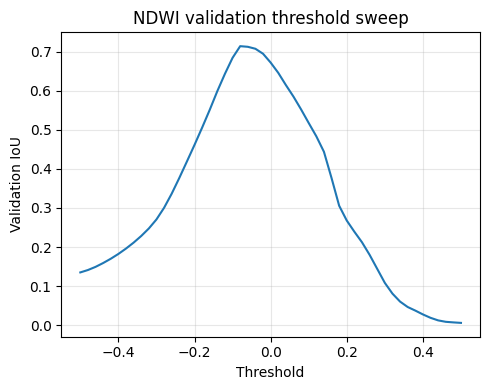

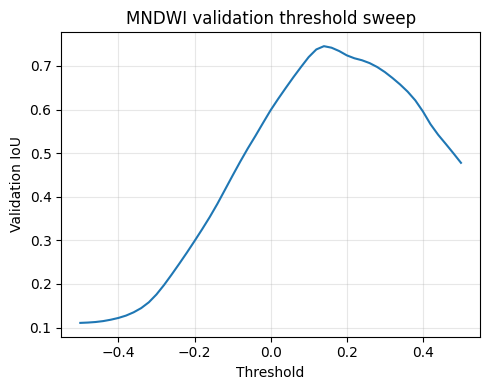

Evaluating NDWI:   0%|          | 0/89 [00:00<?, ?it/s]

Evaluating MNDWI:   0%|          | 0/89 [00:00<?, ?it/s]

NDWI: {'IoU': 0.7359893751622416, 'F1': 0.8479192162031035, 'Precision': 0.78779982722847, 'Recall': 0.9179724737845564, 'Accuracy': 0.958561632737058, 'TP': 2341902, 'FP': 630810, 'FN': 209266, 'TN': 17090925}
MNDWI: {'IoU': 0.7738697494633998, 'F1': 0.872521502435562, 'Precision': 0.8597462301127529, 'Recall': 0.8856821659726052, 'Accuracy': 0.9674319459822799, 'TP': 2259524, 'FP': 368605, 'FN': 291644, 'TN': 17353130}


Sampling pixels for RF:   0%|          | 0/251 [00:00<?, ?it/s]

RF training sample shape: (240000, 13) (240000,)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   39.5s
[Parallel(n_jobs=-1)]: Done 150 out of 150 | elapsed:  2.2min finished


Tuning RF13 threshold:   0%|          | 0/17 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    1.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    2.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    0.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    2.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 150 out of 150 | 

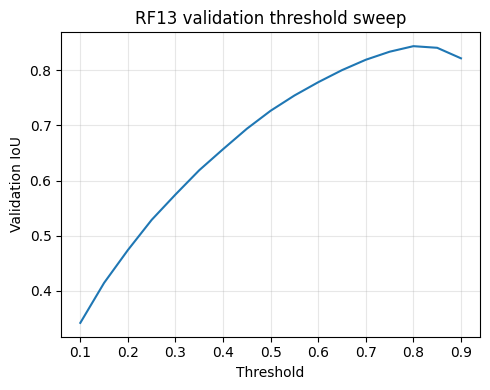

Evaluating RF13:   0%|          | 0/89 [00:00<?, ?it/s]

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    2.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    0.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    2.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    0.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_job

RF13: {'IoU': 0.8488708428957479, 'F1': 0.9182586724838226, 'Precision': 0.9302289103081025, 'Recall': 0.906592588179218, 'Accuracy': 0.9796885034175915, 'TP': 2312870, 'FP': 173475, 'FN': 238298, 'TN': 17548260}


[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    0.8s finished


,Model,IoU,F1,Precision,Recall,Accuracy
0,RF13,0.848871,0.918259,0.930229,0.906593,0.979689
1,MNDWI,0.773870,0.872522,0.859746,0.885682,0.967432
2,NDWI,0.735989,0.847919,0.787800,0.917972,0.958562


In [ ]:
def sample_pixels_from_files(
    files,
    max_pos_per_image=700,
    max_neg_per_image=700,
    global_cap_per_class=120000,
    seed=42
):
    rng = np.random.default_rng(seed)
    X_pos, X_neg = [], []

    for p in tqdm(files, desc="Sampling pixels for RF"):
        img, mask = load_pair(p)
        valid = mask != -1

        pos = np.argwhere(valid & (mask == 1))
        neg = np.argwhere(valid & (mask == 0))

        if len(pos) > 0:
            idx = rng.choice(len(pos), size=min(max_pos_per_image, len(pos)), replace=False)
            coords = pos[idx]
            X_pos.append(img[:, coords[:, 0], coords[:, 1]].T)

        if len(neg) > 0:
            idx = rng.choice(len(neg), size=min(max_neg_per_image, len(neg)), replace=False)
            coords = neg[idx]
            X_neg.append(img[:, coords[:, 0], coords[:, 1]].T)

    X_pos = np.concatenate(X_pos, axis=0)
    X_neg = np.concatenate(X_neg, axis=0)

    if len(X_pos) > global_cap_per_class:
        X_pos = X_pos[rng.choice(len(X_pos), size=global_cap_per_class, replace=False)]
    if len(X_neg) > global_cap_per_class:
        X_neg = X_neg[rng.choice(len(X_neg), size=global_cap_per_class, replace=False)]

    y_pos = np.ones(len(X_pos), dtype=np.uint8)
    y_neg = np.zeros(len(X_neg), dtype=np.uint8)

    X = np.concatenate([X_pos, X_neg], axis=0)
    y = np.concatenate([y_pos, y_neg], axis=0)

    shuffle_idx = rng.permutation(len(y))
    return X[shuffle_idx], y[shuffle_idx]

def train_rf_classifier(X_train, y_train, n_estimators=150, max_depth=25, seed=42):
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        n_jobs=-1,
        random_state=seed,
        class_weight="balanced_subsample",
        verbose=1,
    )
    model.fit(X_train, y_train)
    return model

def predict_rf_proba_image(rf_model, img, chunk_size=200000):
    c, h, w = img.shape
    flat = img.reshape(c, -1).T
    probs = np.zeros(flat.shape[0], dtype=np.float32)

    for start in range(0, flat.shape[0], chunk_size):
        end = min(start + chunk_size, flat.shape[0])
        probs[start:end] = rf_model.predict_proba(flat[start:end])[:, 1]

    return probs.reshape(h, w)

def tune_rf_threshold(files, rf_model, thresholds=np.linspace(0.1, 0.9, 17), model_name="RF13"):
    rows = []
    best_thr, best_iou = 0.5, -1.0

    for thr in tqdm(thresholds, desc=f"Tuning {model_name} threshold"):
        total = (0, 0, 0, 0)
        for p in files:
            img, mask = load_pair(p)
            prob = predict_rf_proba_image(rf_model, img)
            pred = (prob > thr).astype(np.uint8)
            total = add_confusions(total, confusion_counts(pred, mask))
        m = metrics_from_confusion(*total)
        rows.append({"model": model_name, "threshold": float(thr), **m})
        if m["IoU"] > best_iou:
            best_iou = m["IoU"]
            best_thr = float(thr)

    return best_thr, pd.DataFrame(rows)

def evaluate_rf_model(files, rf_model, threshold=0.5, model_name="RF13"):
    total = (0, 0, 0, 0)
    rows = []

    for p in tqdm(files, desc=f"Evaluating {model_name}"):
        img, mask = load_pair(p)
        prob = predict_rf_proba_image(rf_model, img)
        pred = (prob > threshold).astype(np.uint8)

        conf = confusion_counts(pred, mask)
        total = add_confusions(total, conf)
        m = metrics_from_confusion(*conf)
        valid = mask != -1

        rows.append({
            "file": Path(p).name,
            "gt_water_fraction": float((mask[valid] == 1).mean()) if valid.any() else 0.0,
            **m
        })

    return metrics_from_confusion(*total), pd.DataFrame(rows)

# split
train_files, val_files, test_files, split_meta = get_splits(split_mode="auto", split_dir=SPLIT_DIR, seed=42)
print(split_meta)
save_json(split_meta, OUT_DIR / "metrics" / "split_meta.json")

# specteral baseline
thresholds = np.linspace(-0.5, 0.5, 51)

ndwi_thr, ndwi_curve = tune_threshold(val_files, compute_ndwi, thresholds, model_name="NDWI")
mndwi_thr, mndwi_curve = tune_threshold(val_files, compute_mndwi, thresholds, model_name="MNDWI")

plot_threshold_curve(ndwi_curve, "NDWI validation threshold sweep", OUT_DIR / "figures" / "ndwi_threshold_sweep.png")
plot_threshold_curve(mndwi_curve, "MNDWI validation threshold sweep", OUT_DIR / "figures" / "mndwi_threshold_sweep.png")

ndwi_test, ndwi_per_image = evaluate_score_model(test_files, compute_ndwi, ndwi_thr, model_name="NDWI")
mndwi_test, mndwi_per_image = evaluate_score_model(test_files, compute_mndwi, mndwi_thr, model_name="MNDWI")

ndwi_per_image.to_csv(OUT_DIR / "tables" / "ndwi_per_image.csv", index=False)
mndwi_per_image.to_csv(OUT_DIR / "tables" / "mndwi_per_image.csv", index=False)
save_json({"threshold": ndwi_thr, **ndwi_test}, OUT_DIR / "metrics" / "ndwi_test_metrics.json")
save_json({"threshold": mndwi_thr, **mndwi_test}, OUT_DIR / "metrics" / "mndwi_test_metrics.json")

print("NDWI:", ndwi_test)
print("MNDWI:", mndwi_test)

# RF
X_train, y_train = sample_pixels_from_files(
    train_files,
    max_pos_per_image=700,
    max_neg_per_image=700,
    global_cap_per_class=120000,
    seed=42
)
print("RF training sample shape:", X_train.shape, y_train.shape)

rf_model = train_rf_classifier(X_train, y_train, n_estimators=150, max_depth=25, seed=42)
joblib.dump(rf_model, OUT_DIR / "models" / "rf13.joblib")

rf_thr, rf_curve = tune_rf_threshold(val_files, rf_model, thresholds=np.linspace(0.1, 0.9, 17), model_name="RF13")
plot_threshold_curve(rf_curve, "RF13 validation threshold sweep", OUT_DIR / "figures" / "rf13_threshold_sweep.png")

rf_test, rf_per_image = evaluate_rf_model(test_files, rf_model, threshold=rf_thr, model_name="RF13")
rf_per_image.to_csv(OUT_DIR / "tables" / "rf13_per_image.csv", index=False)
save_json({"threshold": rf_thr, **rf_test}, OUT_DIR / "metrics" / "rf13_test_metrics.json")

print("RF13:", rf_test)

# ompare table
comparison_df = build_comparison_table({
    "NDWI": ndwi_test,
    "MNDWI": mndwi_test,
    "RF13": rf_test,
})
display(comparison_df)


In [ ]:
class Sen1FloodsDataset(Dataset):
    def __init__(self, files, augment=False):
        self.files = list(files)
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        s2_path = self.files[idx]
        img, mask = load_pair(s2_path)

        if self.augment:
            if random.random() < 0.5:
                img = img[:, :, ::-1].copy()
                mask = mask[:, ::-1].copy()
            if random.random() < 0.5:
                img = img[:, ::-1, :].copy()
                mask = mask[::-1, :].copy()
            k = random.randint(0, 3)
            if k:
                img = np.rot90(img, k=k, axes=(1, 2)).copy()
                mask = np.rot90(mask, k=k).copy()

        return torch.from_numpy(img.copy()).float(), torch.from_numpy(mask.copy()).long(), Path(s2_path).name

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.seq(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.seq = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.seq(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diff_y = x2.size()[2] - x1.size()[2]
        diff_x = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(
            x1,
            [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2]
        )
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=13, n_classes=2, base_c=32, bilinear=True):
        super().__init__()
        factor = 2 if bilinear else 1

        self.inc = DoubleConv(n_channels, base_c)
        self.down1 = Down(base_c, base_c * 2)
        self.down2 = Down(base_c * 2, base_c * 4)
        self.down3 = Down(base_c * 4, base_c * 8)
        self.down4 = Down(base_c * 8, base_c * 16 // factor)

        self.up1 = Up(base_c * 16, base_c * 8 // factor, bilinear)
        self.up2 = Up(base_c * 8, base_c * 4 // factor, bilinear)
        self.up3 = Up(base_c * 4, base_c * 2 // factor, bilinear)
        self.up4 = Up(base_c * 2, base_c, bilinear)
        self.outc = OutConv(base_c, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

def compute_class_weights(files):
    water = 0
    nonwater = 0

    for p in tqdm(files, desc="Computing class weights"):
        mask = load_label(label_from_s2_path(p))
        valid = mask != -1
        water += int((mask[valid] == 1).sum())
        nonwater += int((mask[valid] == 0).sum())

    pos_weight = nonwater / max(water, 1)
    weights = torch.tensor([1.0, float(pos_weight)], dtype=torch.float32)

    meta = {
        "water_pixels": int(water),
        "nonwater_pixels": int(nonwater),
        "pos_weight": float(pos_weight),
    }
    return weights, meta

@torch.no_grad()
def evaluate_unet(model, loader, device):
    model.eval()
    total = (0, 0, 0, 0)
    rows = []

    for images, masks, names in tqdm(loader, desc="Evaluating U-Net", leave=False):
        images = images.to(device, non_blocking=True)
        logits = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        masks_np = masks.numpy()

        for pred, gt, name in zip(preds, masks_np, names):
            conf = confusion_counts(pred, gt)
            total = add_confusions(total, conf)
            m = metrics_from_confusion(*conf)
            valid = gt != -1
            rows.append({
                "file": name,
                "gt_water_fraction": float((gt[valid] == 1).mean()) if valid.any() else 0.0,
                **m
            })

    return metrics_from_confusion(*total), pd.DataFrame(rows)

def train_unet_fixed(
    train_files,
    val_files,
    test_files,
    run_name="unet_fixed_noaug",
    epochs=10,
    batch_size=None,
    lr=1e-3,
    weight_decay=1e-4,
    base_c=None,
    num_workers=2,
    augment=False,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if batch_size is None:
        batch_size = 4 if device.type == "cuda" else 2
    if base_c is None:
        base_c = 64 if device.type == "cuda" else 32

    train_ds = Sen1FloodsDataset(train_files, augment=augment)
    val_ds = Sen1FloodsDataset(val_files, augment=False)
    test_ds = Sen1FloodsDataset(test_files, augment=False)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=(device.type == "cuda")
    )
    val_loader = DataLoader(
        val_ds, batch_size=1, shuffle=False,
        num_workers=num_workers, pin_memory=(device.type == "cuda")
    )
    test_loader = DataLoader(
        test_ds, batch_size=1, shuffle=False,
        num_workers=num_workers, pin_memory=(device.type == "cuda")
    )

    model = UNet(n_channels=13, n_classes=2, base_c=base_c).to(device)

    class_weights, class_meta = compute_class_weights(train_files)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), ignore_index=-1)


    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2
    )

    history = []
    best_val_iou = -1.0
    ckpt_path = OUT_DIR / "checkpoints" / f"{run_name}_best.pt"

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for images, masks, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        train_loss = running_loss / max(len(train_loader.dataset), 1)
        val_metrics, _ = evaluate_unet(model, val_loader, device)
        scheduler.step(val_metrics["IoU"])

        history_row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "lr": optimizer.param_groups[0]["lr"],
            **val_metrics
        }
        history.append(history_row)
        print(history_row)

        if val_metrics["IoU"] > best_val_iou:
            best_val_iou = val_metrics["IoU"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_metrics": val_metrics,
                "class_meta": class_meta,
                "config": {
                    "run_name": run_name,
                    "epochs": epochs,
                    "batch_size": batch_size,
                    "lr": lr,
                    "weight_decay": weight_decay,
                    "base_c": base_c,
                    "augment": augment,
                }
            }, ckpt_path)

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUT_DIR / "history" / f"{run_name}_history.csv", index=False)

    best_ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(best_ckpt["model_state_dict"])

    test_metrics, per_image_df = evaluate_unet(model, test_loader, device)
    per_image_df.to_csv(OUT_DIR / "tables" / f"{run_name}_per_image.csv", index=False)
    save_json(test_metrics, OUT_DIR / "metrics" / f"{run_name}_test_metrics.json")

    return model, history_df, test_metrics, per_image_df, ckpt_path

@torch.no_grad()
def predict_unet_mask(model, s2_path, device=None):
    if device is None:
        device = next(model.parameters()).device
    img = load_s2_image(s2_path)
    x = torch.from_numpy(img).unsqueeze(0).float().to(device)
    pred = model(x).argmax(dim=1)[0].cpu().numpy().astype(np.uint8)
    return pred


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

True
Tesla T4


In [ ]:
model_smoke, hist_smoke, unet_smoke_test, _, ckpt_smoke = train_unet_fixed(
    train_files=train_files,
    val_files=val_files,
    test_files=test_files,
    run_name="unet_fixed_smoke",
    epochs=1,
    batch_size=2 if DEVICE.type == "cpu" else 4,
    base_c=32 if DEVICE.type == "cpu" else 64,
    augment=False,
    num_workers=2,
)
print("Smoke-test metrics:", unet_smoke_test)



Computing class weights:   0%|          | 0/251 [00:00<?, ?it/s]

Epoch 1/1:   0%|          | 0/63 [00:00<?, ?it/s]

Evaluating U-Net:   0%|          | 0/88 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.32460690512362705, 'lr': 0.001, 'IoU': 0.6336874203675364, 'F1': 0.7757756012162639, 'Precision': 0.6730365258849585, 'Recall': 0.915531561647386, 'Accuracy': 0.9416487289184752, 'TP': 2048598, 'FP': 995216, 'FN': 189007, 'TN': 17061904}


Evaluating U-Net:   0%|          | 0/89 [00:00<?, ?it/s]

Smoke-test metrics: {'IoU': 0.7094086262527697, 'F1': 0.8300047342195519, 'Precision': 0.7338068493200182, 'Recall': 0.9552299182178512, 'Accuracy': 0.9507600860123486, 'TP': 2436952, 'FP': 884020, 'FN': 114216, 'TN': 16837715}


In [ ]:
model_unet, hist_unet, unet_test, unet_per_image, ckpt_unet = train_unet_fixed(
    train_files=train_files,
    val_files=val_files,
    test_files=test_files,
    run_name="unet_fixed_noaug",
    epochs=15,
    batch_size=4,
    base_c=64,
    augment=False,
    num_workers=2,
)
print("Final corrected U-Net test metrics:", unet_test)

Computing class weights:   0%|          | 0/251 [00:00<?, ?it/s]

Epoch 1/15:   0%|          | 0/63 [00:00<?, ?it/s]

Evaluating U-Net:   0%|          | 0/88 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.32118778239445855, 'lr': 0.001, 'IoU': 0.5070005031231408, 'F1': 0.6728604298040006, 'Precision': 0.5129290183540034, 'Recall': 0.9777109900987883, 'Accuracy': 0.8951788703714881, 'TP': 2187731, 'FP': 2077442, 'FN': 49874, 'TN': 15979678}


Epoch 2/15:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 15/15:   0%|          | 0/63 [00:00<?, ?it/s]

Evaluating U-Net:   0%|          | 0/88 [00:00<?, ?it/s]

{'epoch': 15, 'train_loss': 0.1655575244194008, 'lr': 0.00025, 'IoU': 0.643394467826573, 'F1': 0.7830067344421293, 'Precision': 0.6527315905989673, 'Recall': 0.9782504061261925, 'Accuracy': 0.9402192934370878, 'TP': 2188938, 'FP': 1164566, 'FN': 48667, 'TN': 16892554}


Evaluating U-Net:   0%|          | 0/89 [00:00<?, ?it/s]

Final corrected U-Net test metrics: {'IoU': 0.7592150844545369, 'F1': 0.863129348040964, 'Precision': 0.779993613683553, 'Recall': 0.9661014092368668, 'Accuracy': 0.9614423745824661, 'TP': 2464687, 'FP': 695194, 'FN': 86481, 'TN': 17026541}


In [ ]:
comparison_df = pd.DataFrame([
    {"Model": "NDWI", "IoU": 0.735989, "F1": 0.847919, "Precision": 0.787800, "Recall": 0.917972, "Accuracy": 0.958562},
    {"Model": "MNDWI", "IoU": 0.773870, "F1": 0.872522, "Precision": 0.859746, "Recall": 0.885682, "Accuracy": 0.967432},
    {"Model": "RF13", "IoU": 0.848871, "F1": 0.918259, "Precision": 0.930229, "Recall": 0.906593, "Accuracy": 0.979689},
    {"Model": "U-Net13-fixed", **unet_test},
])

comparison_df = comparison_df.sort_values("IoU", ascending=False).reset_index(drop=True)
comparison_df.to_csv(OUT_DIR / "tables" / "model_comparison.csv", index=False)
display(comparison_df)

,Model,IoU,F1,Precision,Recall,Accuracy,TP,FP,FN,TN
0,RF13,0.848871,0.918259,0.930229,0.906593,0.979689,NaN,NaN,NaN,NaN
1,MNDWI,0.773870,0.872522,0.859746,0.885682,0.967432,NaN,NaN,NaN,NaN
2,U-Net13-fixed,0.759215,0.863129,0.779994,0.966101,0.961442,2464687.0,695194.0,86481.0,17026541.0
3,NDWI,0.735989,0.847919,0.787800,0.917972,0.958562,NaN,NaN,NaN,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!find /content/drive/MyDrive/eo_water_backup -maxdepth 4 | sort

Mounted at /content/drive
/content/drive/MyDrive/eo_water_backup
/content/drive/MyDrive/eo_water_backup/outputs
/content/drive/MyDrive/eo_water_backup/outputs/checkpoints
/content/drive/MyDrive/eo_water_backup/outputs/figures
/content/drive/MyDrive/eo_water_backup/outputs/figures/mndwi_threshold_sweep.png
/content/drive/MyDrive/eo_water_backup/outputs/figures/ndwi_threshold_sweep.png
/content/drive/MyDrive/eo_water_backup/outputs/figures/rf13_threshold_sweep.png
/content/drive/MyDrive/eo_water_backup/outputs/history
/content/drive/MyDrive/eo_water_backup/outputs/metrics
/content/drive/MyDrive/eo_water_backup/outputs/metrics/mndwi_test_metrics.json
/content/drive/MyDrive/eo_water_backup/outputs/metrics/ndwi_test_metrics.json
/content/drive/MyDrive/eo_water_backup/outputs/metrics/rf13_test_metrics.json
/content/drive/MyDrive/eo_water_backup/outputs/metrics/split_meta.json
/content/drive/MyDrive/eo_water_backup/outputs/models
/content/drive/MyDrive/eo_water_backup/outputs/models/rf13.jobl

In [ ]:
import json
from pathlib import Path

backup_out = Path("/content/drive/MyDrive/eo_water_backup/outputs")

with open(backup_out / "metrics" / "ndwi_test_metrics.json", "r") as f:
    ndwi_metrics = json.load(f)
ndwi_thr = ndwi_metrics["threshold"]

with open(backup_out / "metrics" / "rf13_test_metrics.json", "r") as f:
    rf_metrics = json.load(f)
rf_thr = rf_metrics["threshold"]

print("ndwi_thr:", ndwi_thr)
print("rf_thr:", rf_thr)

ndwi_thr: -0.08000000000000002
rf_thr: 0.8


In [ ]:
def choose_representative_examples(per_image_df, all_test_files):
    df = per_image_df.copy()
    if "gt_water_fraction" in df.columns:
        df = df[df["gt_water_fraction"] > 0.005].copy()
    df = df.sort_values("IoU").reset_index(drop=True)

    if len(df) < 3:
        chosen_names = df["file"].tolist()[:3]
    else:
        chosen_names = [
            df.iloc[-1]["file"],            # best
            df.iloc[len(df) // 2]["file"],  # middle
            df.iloc[0]["file"],             # hardest
        ]

    lookup = {Path(p).name: p for p in all_test_files}
    return [lookup[name] for name in chosen_names if name in lookup]

def make_qualitative_figure(example_files, ndwi_thr, rf_model, rf_thr, unet_model, save_path):
    n = len(example_files)
    cols = 5
    fig, axes = plt.subplots(n, cols, figsize=(16, 3.5 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    col_titles = ["RGB", "Ground Truth", "NDWI", "RF13", "U-Net13"]
    for j, t in enumerate(col_titles):
        axes[0, j].set_title(t)

    for i, s2_path in enumerate(example_files):
        img, mask = load_pair(s2_path)

        ndwi_pred = (compute_ndwi(img) > ndwi_thr).astype(np.uint8)
        rf_pred = (predict_rf_proba_image(rf_model, img) > rf_thr).astype(np.uint8)
        unet_pred = predict_unet_mask(unet_model, s2_path)

        panels = [
            rgb_from_s2(img),
            mask,
            ndwi_pred,
            rf_pred,
            unet_pred,
        ]

        cmaps = [None, "gray", "gray", "gray", "gray"]

        for j, (panel, cmap) in enumerate(zip(panels, cmaps)):
            ax = axes[i, j]
            if cmap is None:
                ax.imshow(panel)
            else:
                ax.imshow(panel, cmap=cmap, vmin=0, vmax=1)
            ax.axis("off")

        axes[i, 0].set_ylabel(Path(s2_path).stem, fontsize=8)

    plt.tight_layout()
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

In [ ]:
def predict_rf_proba_image(rf_model, img, chunk_size=200000):
    c, h, w = img.shape
    flat = img.reshape(c, -1).T
    probs = np.zeros(flat.shape[0], dtype=np.float32)

    for start in range(0, flat.shape[0], chunk_size):
        end = min(start + chunk_size, flat.shape[0])
        probs[start:end] = rf_model.predict_proba(flat[start:end])[:, 1]

    return probs.reshape(h, w)

['Sri-Lanka_713926_S2Hand.tif', 'India_399883_S2Hand.tif', 'Pakistan_849790_S2Hand.tif']


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    1.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    0.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    2.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 150 out of 150 | elapsed:    1.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.6s
[Parallel(n_job

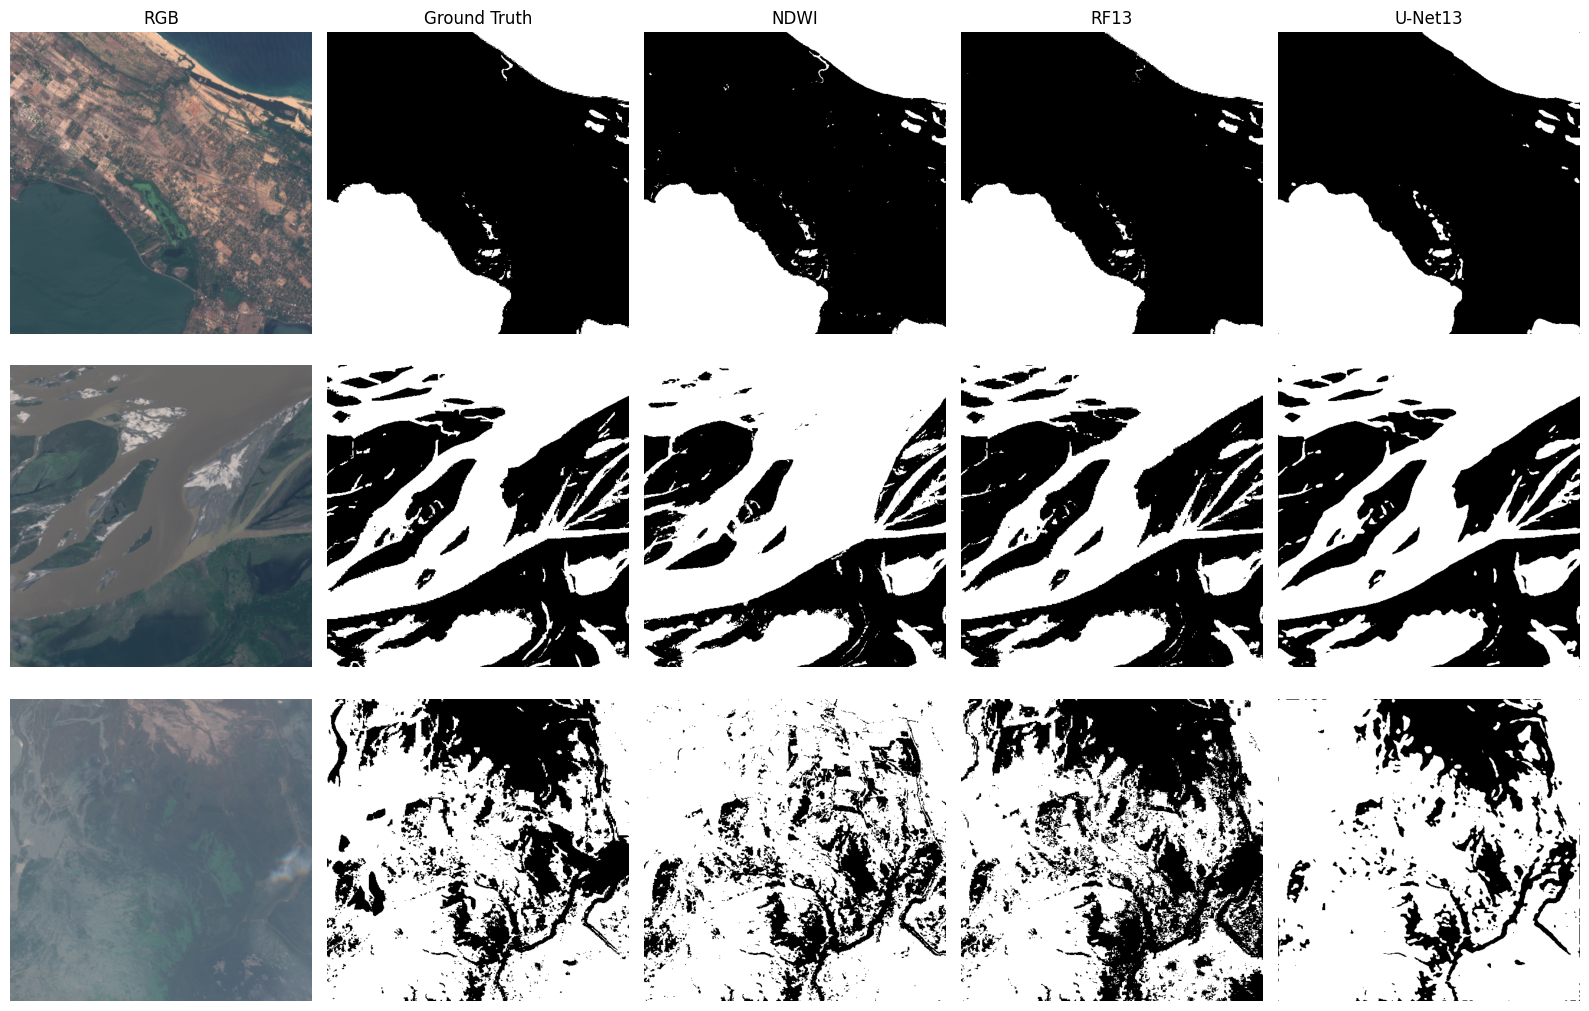

In [ ]:
example_names = [
    "Sri-Lanka_713926_S2Hand.tif",
    "India_399883_S2Hand.tif",
    "Pakistan_849790_S2Hand.tif",
]
lookup = {Path(p).name: p for p in test_files}
example_files = [lookup[name] for name in example_names if name in lookup]

print([Path(p).name for p in example_files])
make_qualitative_figure(
    example_files=example_files,
    ndwi_thr=ndwi_thr,
    rf_model=rf_model,
    rf_thr=rf_thr,
    unet_model=model_unet,
    save_path=OUT_DIR / "figures" / "qualitative_comparison.png",
)